In [1]:
import os
import random
from pathlib import Path

import torchaudio

from matplotlib import pyplot as plt
from IPython.display import Audio, display

In [2]:
audio_dir = Path("./data/datasets/librispeech/test-clean/")
test_audio_dir = audio_dir / random.choice(os.listdir(audio_dir))
test_audio_dir = test_audio_dir / random.choice(os.listdir(test_audio_dir))
test_audio_file = test_audio_dir / random.choice(os.listdir(test_audio_dir))

In [3]:
test_audio, sr = torchaudio.load(test_audio_file)

c:\Users\setday\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Test audio file: data\datasets\librispeech\test-clean\2961\960\2961-960-0016.flac
Sample rate: 16000
Audio shape: torch.Size([1, 124160])
First 10 samples: tensor([[-0.0009, -0.0021, -0.0022, -0.0022, -0.0021, -0.0016, -0.0020, -0.0020,
         -0.0020, -0.0014]])


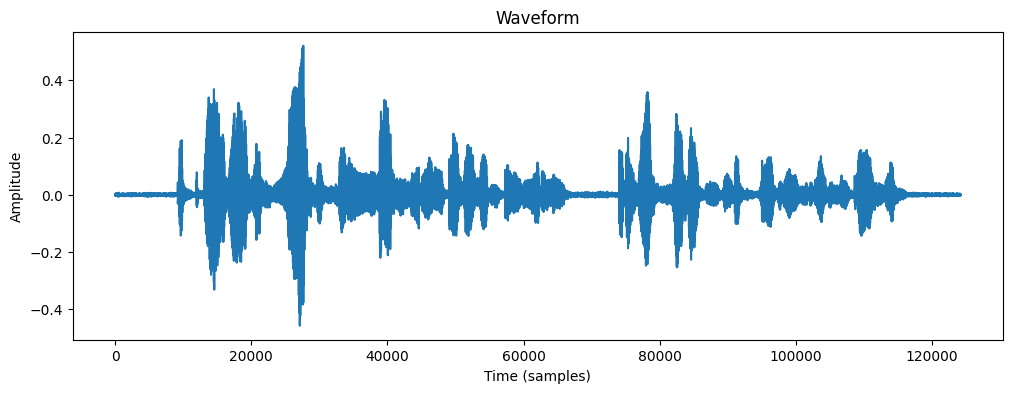

In [4]:
# show audio file path
print("Test audio file:", test_audio_file)
print("Sample rate:", sr)
print("Audio shape:", test_audio.shape)
print("First 10 samples:", test_audio[:, :10])

plt.figure(figsize=(12, 4))
plt.plot(test_audio.t().numpy())
plt.title("Waveform")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

display(Audio(test_audio.numpy(), rate=sr))

In [5]:
from src.transforms.wav_augs import TimeStretch, AddBackgroundNoise, PitchShift, FrequencyMasking, Gain, BitRegression

transforms = [
    TimeStretch(min_rate=0.75, max_rate=0.75, p=1.0),
    TimeStretch(min_rate=1.5, max_rate=1.5, p=1.0),

    AddBackgroundNoise(min_snr_db=30, max_snr_db=30, p=1.0),
    AddBackgroundNoise(min_snr_db=15, max_snr_db=15, p=1.0),

    PitchShift(min_semitones=-20, max_semitones=20, p=1.0),
    
    Gain(min_gain_db=-30, max_gain_db=-30, p=1.0),

    FrequencyMasking(p=1.0),
    BitRegression(p=1.0)
]

c:\Users\setday\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_audiomentations\core\transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = PitchShift(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(


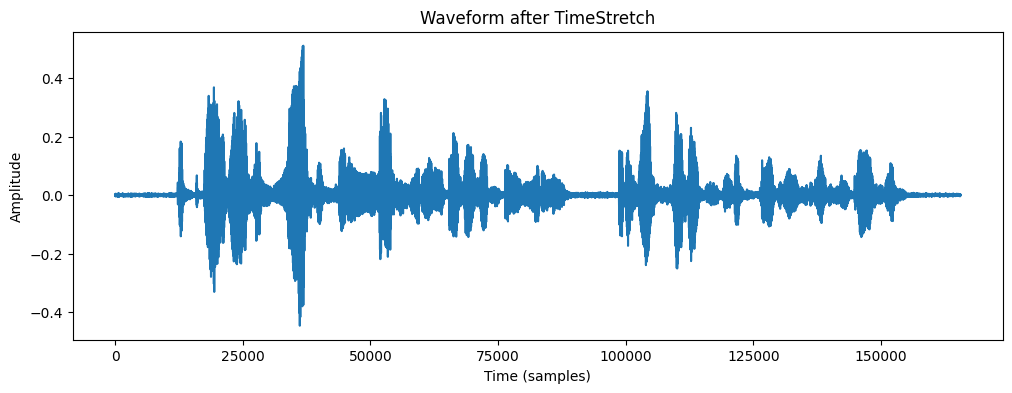

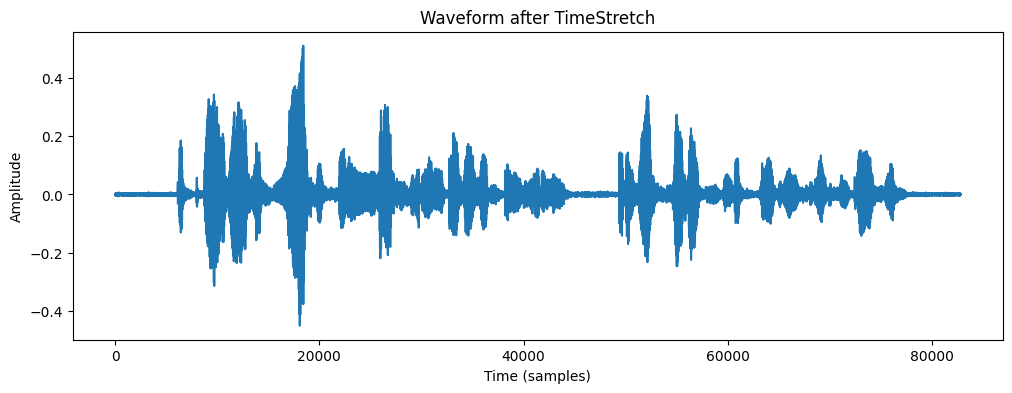

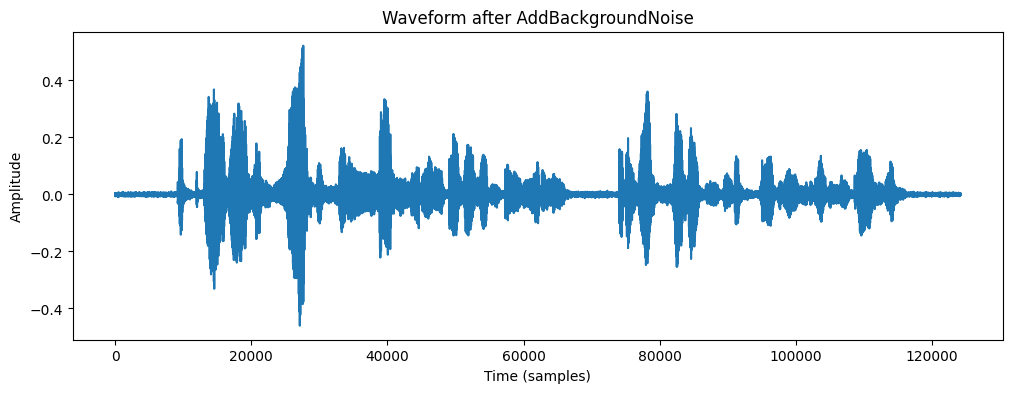

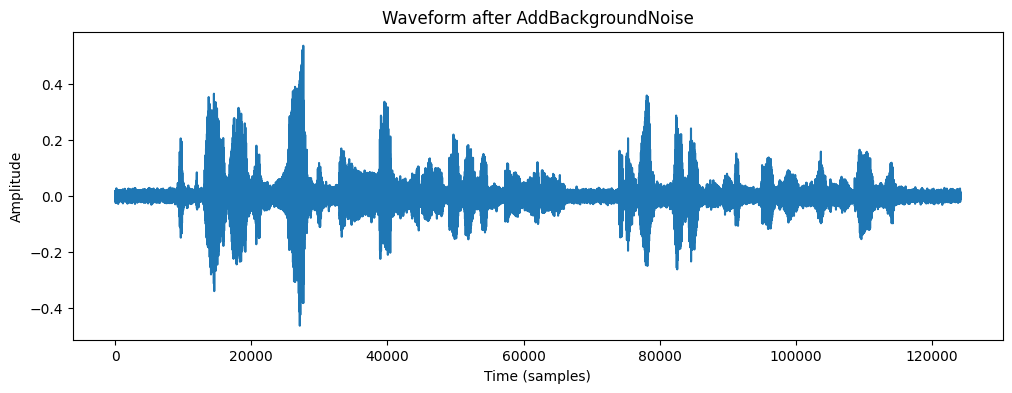

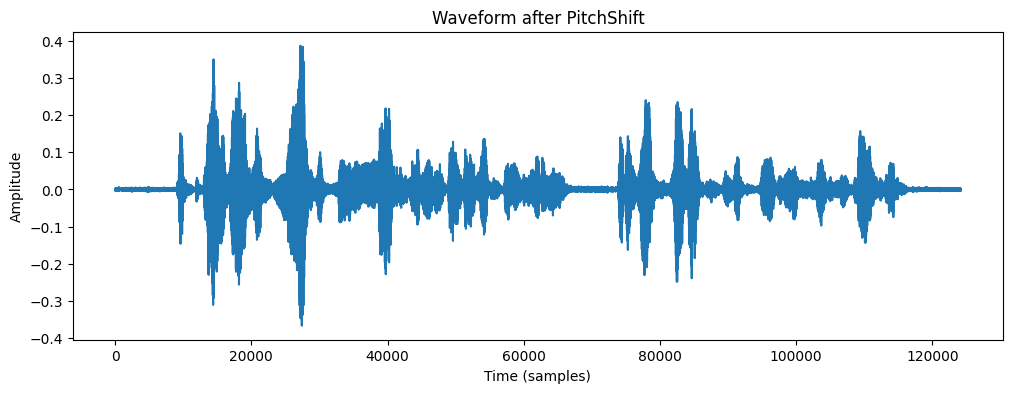

tensor([0.0316])


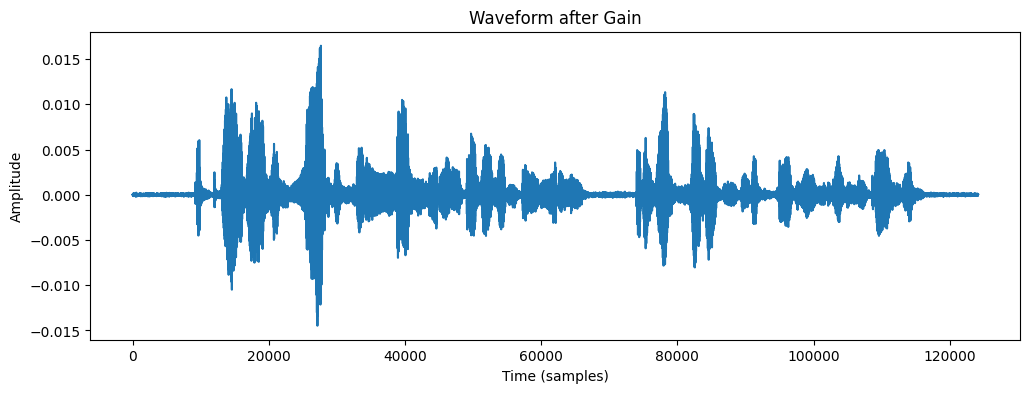

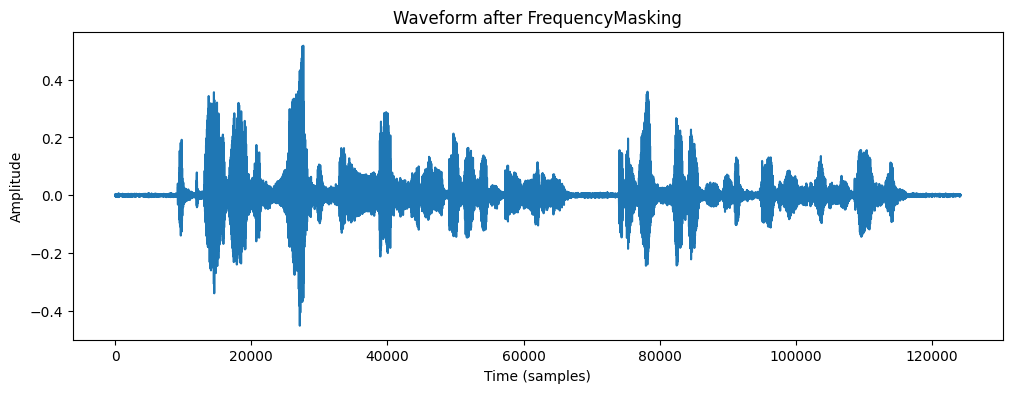

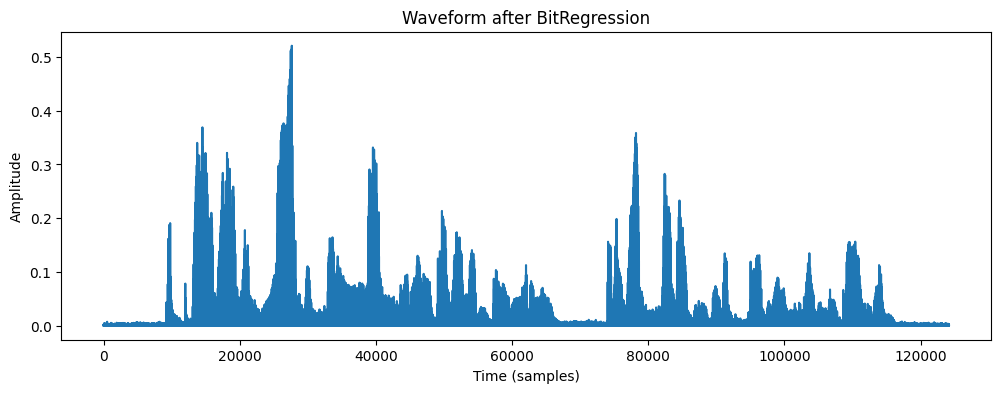

In [6]:
for transform in transforms:
    augmented_audio = transform(test_audio)

    plt.figure(figsize=(12, 4))
    plt.plot(augmented_audio.t().numpy())
    plt.title(f"Waveform after {transform.__class__.__name__}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.show()

    display(Audio(augmented_audio.numpy(), rate=sr))

In [7]:
from src.transforms.spec_augs import SpecAugment, TimeMasking, FrequencyMasking

spec_transforms = [
    SpecAugment(p=1.0),
    TimeMasking(p=1.0),
    FrequencyMasking(p=1.0)
]

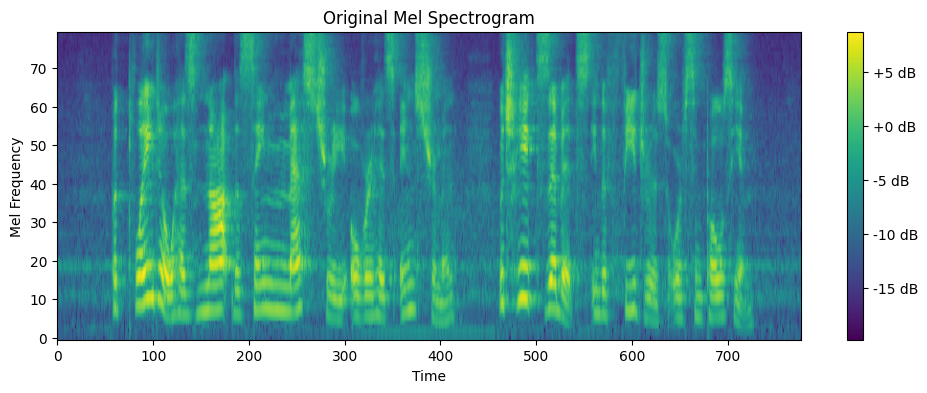

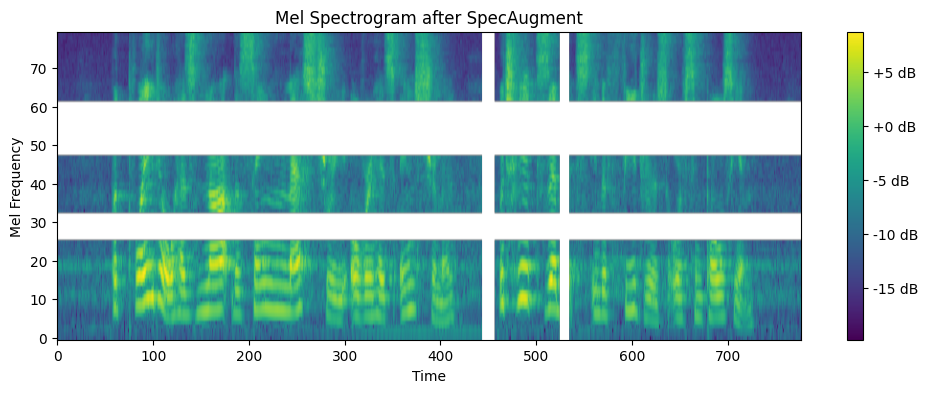

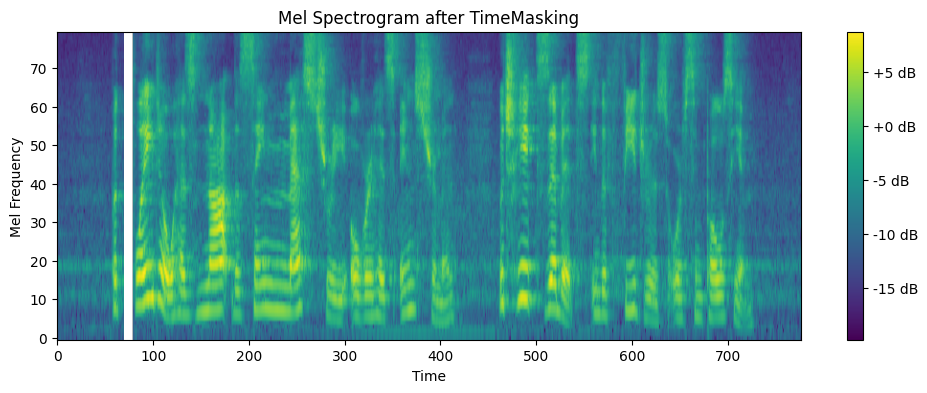

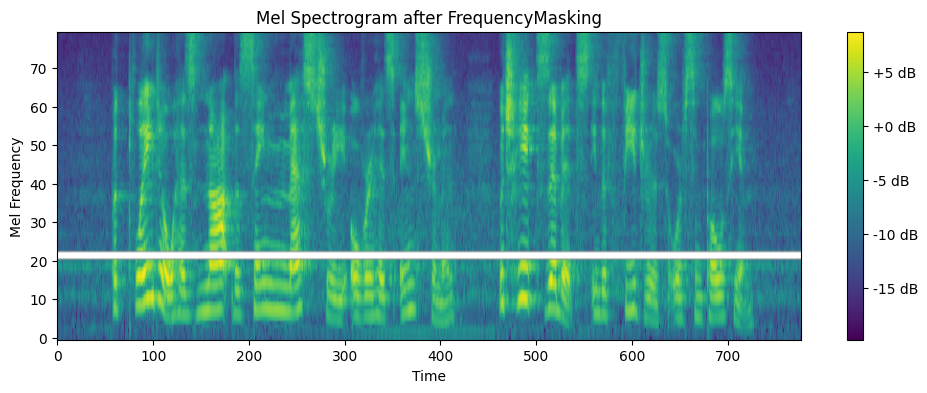

In [8]:
from torchaudio.transforms import MelSpectrogram

mel_spectrogram = MelSpectrogram(sample_rate=16000, n_fft=512, win_length=400, hop_length=160, n_mels=80, f_min=0, f_max=8000)(test_audio)

plt.figure(figsize=(12, 4))
plt.imshow(mel_spectrogram.log2()[0,:,:].numpy(), aspect='auto', origin='lower')
plt.title("Original Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar(format="%+2.0f dB")
plt.show()

for spec_transform in spec_transforms:
    augmented_spectrogram = spec_transform(mel_spectrogram)

    plt.figure(figsize=(12, 4))
    plt.imshow(augmented_spectrogram.log2()[0,:,:].numpy(), aspect='auto', origin='lower')
    plt.title(f"Mel Spectrogram after {spec_transform.__class__.__name__}")
    plt.xlabel("Time")
    plt.ylabel("Mel Frequency")
    plt.colorbar(format="%+2.0f dB")
    plt.show()